# 02 — Modeling
Somalia Displacement Event Severity Classifier

## Phase 1 — Imports & Load Clean Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from xgboost import XGBClassifier

os.makedirs("../models", exist_ok=True)

df = pd.read_csv("../dataset/clean_dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (3091, 9)


,displacement_type,combined_type,month,duration_days,latitude,longitude,year,region,is_large_event
0,Disaster,Flood,4,6,2.116670,45.400002,2026,Other,1
1,Conflict,Conflict,2,6,2.122640,45.274020,2026,Other,0
2,Disaster,Drought,2,6,0.633830,42.742885,2026,Middle Juba,0
3,Disaster,Drought,2,6,0.419905,42.643080,2026,Middle Juba,0
4,Disaster,Drought,2,6,2.122640,45.274020,2026,Other,0


In [4]:
df['is_large_event'].value_counts()

is_large_event
0    2696
1     395
Name: count, dtype: int64

## Phase 2 — Prepare Features & Target

In [5]:
# Encode categorical columns
le_combined   = LabelEncoder()
le_displace   = LabelEncoder()
le_region     = LabelEncoder()

df['combined_type_enc']     = le_combined.fit_transform(df['combined_type'])
df['displacement_type_enc'] = le_displace.fit_transform(df['displacement_type'])
df['region_enc']            = le_region.fit_transform(df['region'])

print("combined_type classes:", le_combined.classes_)
print("displacement_type classes:", le_displace.classes_)
print("region classes:", le_region.classes_)

combined_type classes: ['Conflict' 'Drought' 'Flood']
displacement_type classes: ['Conflict' 'Disaster']
region classes: ['Bakool' 'Banaadir' 'Bari' 'Bay' 'Gedo' 'Hiiraan' 'Lower Juba'
 'Middle Juba' 'Mudug' 'Other' 'Sanaag']


In [6]:
FEATURES = [
    'combined_type_enc',
    'displacement_type_enc',
    'region_enc',
    'month',
    'duration_days',
    'latitude',
    'longitude',
    'year',
]

X = df[FEATURES]
y = df['is_large_event']

print("X shape:", X.shape)
print("y distribution:")
print(y.value_counts())

X shape: (3091, 8)
y distribution:
is_large_event
0    2696
1     395
Name: count, dtype: int64


## Phase 3 — Train/Test Split & Scaling

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 2472
Test size: 619


In [8]:
scaler = StandardScaler()

# Scale only continuous columns — leave encoded categoricals as-is
scale_cols = ['month', 'duration_days', 'latitude', 'longitude', 'year']

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols]  = scaler.transform(X_test[scale_cols])

print("Scaling done.")

Scaling done.


## Phase 4 — Train Logistic Regression

In [9]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
print("Logistic Regression trained.")

Logistic Regression trained.


## Phase 5 — Train Random Forest

In [10]:
rf = RandomForestClassifier(
    n_estimators=100, random_state=42, class_weight='balanced'
)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)
print("Random Forest trained.")

Random Forest trained.


## Phase 6 — Train XGBoost

In [11]:
# scale_pos_weight handles imbalance: ratio of negative to positive
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
ratio = neg / pos
print(f"scale_pos_weight = {ratio:.2f}")

xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    scale_pos_weight=ratio,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb.fit(X_train_scaled, y_train)
xgb_pred = xgb.predict(X_test_scaled)
print("XGBoost trained.")

scale_pos_weight = 6.82
XGBoost trained.


c:\Users\HP\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:58:27] WARNING: C:\Users\task_177740979073858\croot\xgboost-split_1777409985184\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Phase 7 — Compare All Models

In [12]:
def get_metrics(name, y_true, y_pred):
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 3),
        'Precision': round(precision_score(y_true, y_pred), 3),
        'Recall':    round(recall_score(y_true, y_pred), 3),
        'F1-Score':  round(f1_score(y_true, y_pred), 3),
    }

results = pd.DataFrame([
    get_metrics("Logistic Regression", y_test, lr_pred),
    get_metrics("Random Forest",       y_test, rf_pred),
    get_metrics("XGBoost",             y_test, xgb_pred),
])

print(results.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression     0.604      0.145   0.430     0.217
      Random Forest     0.868      0.484   0.557     0.518
            XGBoost     0.838      0.421   0.709     0.528


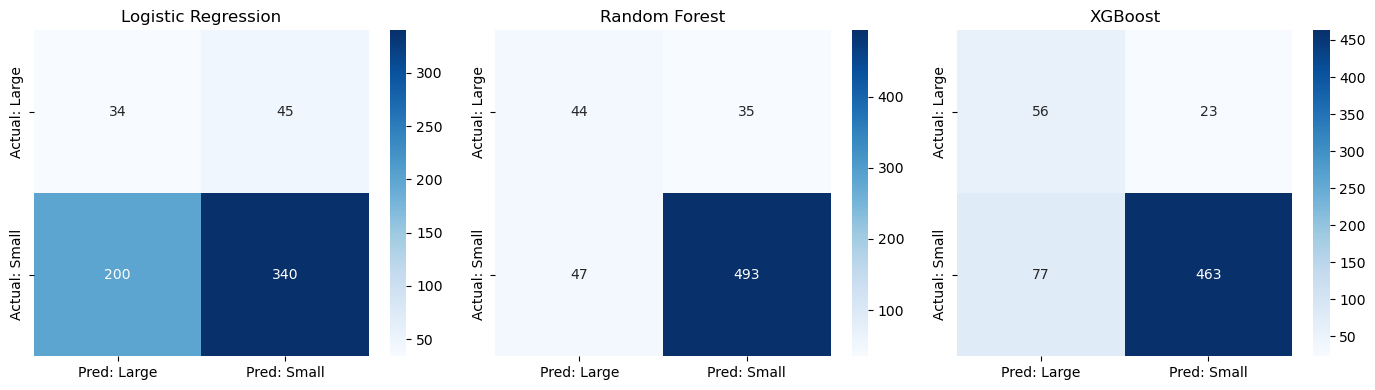

In [13]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, pred) in zip(axes, [
    ("Logistic Regression", lr_pred),
    ("Random Forest",       rf_pred),
    ("XGBoost",             xgb_pred),
]):
    cm = confusion_matrix(y_test, pred, labels=[1, 0])
    cm_df = pd.DataFrame(
        cm,
        index=["Actual: Large", "Actual: Small"],
        columns=["Pred: Large", "Pred: Small"]
    )
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [14]:
# Best model by Recall (humanitarian priority — don't miss large events)
best_row = results.loc[results['Recall'].idxmax()]
print(f"Best model by Recall: {best_row['Model']}")
print(best_row)

Best model by Recall: XGBoost
Model        XGBoost
Accuracy       0.838
Precision      0.421
Recall         0.709
F1-Score       0.528
Name: 2, dtype: object


## Phase 8 — Sanity Checks on Best Model

In [15]:
# Using XGBoost as best model — update if results differ
best_model = xgb

for i in [0, 5, 10]:
    x_one   = X_test_scaled.iloc[[i]]
    y_true  = y_test.iloc[i]
    y_pred  = int(best_model.predict(x_one)[0])
    y_prob  = float(best_model.predict_proba(x_one)[0][1])
    label   = "Large Event" if y_pred == 1 else "Small Event"
    actual  = "Large Event" if y_true == 1 else "Small Event"
    print(f"Row {i} — Actual: {actual} | Predicted: {label} | Probability: {y_prob:.2f}")

Row 0 — Actual: Small Event | Predicted: Small Event | Probability: 0.01
Row 5 — Actual: Small Event | Predicted: Small Event | Probability: 0.00
Row 10 — Actual: Small Event | Predicted: Large Event | Probability: 0.90


## Phase 9 — Save Models & Artifacts

In [16]:
joblib.dump(lr,  "../models/lr_model.pkl")
joblib.dump(rf,  "../models/rf_model.pkl")
joblib.dump(xgb, "../models/best_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump({
    'combined_type':     le_combined,
    'displacement_type': le_displace,
    'region':            le_region,
}, "../models/label_encoders.pkl")

['../models/label_encoders.pkl']